In [ ]:
import pandas as pd

# 데이터 로드
train = pd.read_csv('/content/drive/MyDrive/ROSSMANN/train.csv')
store = pd.read_csv('/content/drive/MyDrive/ROSSMANN/store.csv')

# 첫 탐색 - 직접 확인해볼 것들
train.shape
train.head()
train.info()
train['Sales'].describe()

/tmp/ipykernel_1360/1833700839.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/content/drive/MyDrive/ROSSMANN/train.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04


In [ ]:
train['Date'].min(), train['Date'].max()  # 데이터 기간

('2013-01-01', '2015-07-31')

In [ ]:
train['Store'].nunique()  # 매장 수

1115

In [ ]:
# Open 값 분포
print(train['Open'].value_counts())

# Open별 Sales 평균
print(train.groupby('Open')['Sales'].mean())

# Open=1인데 Sales=0인 이상 케이스 확인
print(((train['Open']==1) & (train['Sales']==0)).sum())

Open
1    844392
0    172817
Name: count, dtype: int64
Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64
54


In [ ]:
# 어떤 값들이 있는지 + 타입 섞임 확인
print(train['StateHoliday'].value_counts())
print(train['StateHoliday'].apply(type).value_counts())

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64
StateHoliday
<class 'str'>    886137
<class 'int'>    131072
Name: count, dtype: int64


In [ ]:
print(store.shape)
print(store.head())
print(store.info())

# 컬럼별 결측치 개수
print(store.isnull().sum())

(1115, 10)
   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   
3      4         c          c                620.0                        9.0   
4      5         a          a              29910.0                        4.0   

   CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  \
0                    2008.0       0              NaN              NaN   
1                    2007.0       1             13.0           2010.0   
2                    2006.0       1             14.0           2011.0   
3                    2009.0       0              NaN              NaN   
4                    2015.0       0              NaN              NaN   

     PromoInterval  
0              NaN  
1  Jan,Apr,Jul,Oct  


In [ ]:
# 영업일만 남기기 (휴무일 제거)
train = train[train['Open'] == 1].copy()

# 영업인데 매출 0인 이상치 제거
train = train[train['Sales'] > 0].copy()

print(train.shape)  # 행 수 줄어든 것 확인

(844338, 9)


In [ ]:
# 전부 문자열로 통일
train['StateHoliday'] = train['StateHoliday'].astype(str)

print(train['StateHoliday'].value_counts())
print(train['StateHoliday'].apply(type).value_counts())  # str만 남는지 확인

StateHoliday
0    843428
a       694
b       145
c        71
Name: count, dtype: int64
StateHoliday
<class 'str'>    844338
Name: count, dtype: int64


In [ ]:
# Date가 지금 object(문자)라 datetime으로 변환해야 시계열 처리 가능
train['Date'] = pd.to_datetime(train['Date'])

print(train['Date'].dtype)  # datetime64로 바뀌는지 확인
print(train['Date'].min(), train['Date'].max())

datetime64[ns]
2013-01-01 00:00:00 2015-07-31 00:00:00


In [ ]:
# Store 기준으로 두 데이터 결합 (left join)
df = train.merge(store, on='Store', how='left')

print(df.shape)
print(df.isnull().sum())  # 합친 후 결측치 확인

(844338, 18)
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2                            0
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
dtype: int64


In [ ]:
# 경쟁점 거리: 중앙값으로 채움
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

# Promo2 관련: 프로모션 없음 → 0으로 채움
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

# 경쟁점 개점 시기: 이번엔 미사용, 0으로 채움
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

# 결측치 다 사라졌는지 확인
print(df.isnull().sum())

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


In [ ]:
# 날짜에서 시간 요소 추출
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# 월초/월말 같은 패턴
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

print(df[['Date','Year','Month','Day','WeekOfYear','IsMonthEnd']].head())

        Date  Year  Month  Day  WeekOfYear  IsMonthEnd
0 2015-07-31  2015      7   31          31           1
1 2015-07-31  2015      7   31          31           1
2 2015-07-31  2015      7   31          31           1
3 2015-07-31  2015      7   31          31           1
4 2015-07-31  2015      7   31          31           1


In [ ]:
# 매장별 + 날짜순 정렬 (필수)
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# 시차 변수: 매장별로 N일 전 매출
df['Sales_lag_1'] = df.groupby('Store')['Sales'].shift(1)    # 어제(직전 영업일)
df['Sales_lag_7'] = df.groupby('Store')['Sales'].shift(7)    # 7영업일 전

# 이동평균: 매장별 최근 7일 평균 (shift로 미래 누수 방지)
df['Sales_roll_mean_7'] = df.groupby('Store')['Sales'].shift(1).rolling(7).mean().reset_index(0, drop=True)

print(df[['Store','Date','Sales','Sales_lag_1','Sales_lag_7','Sales_roll_mean_7']].head(10))

   Store       Date  Sales  Sales_lag_1  Sales_lag_7  Sales_roll_mean_7
0      1 2013-01-02   5530          NaN          NaN                NaN
1      1 2013-01-03   4327       5530.0          NaN                NaN
2      1 2013-01-04   4486       4327.0          NaN                NaN
3      1 2013-01-05   4997       4486.0          NaN                NaN
4      1 2013-01-07   7176       4997.0          NaN                NaN
5      1 2013-01-08   5580       7176.0          NaN                NaN
6      1 2013-01-09   5471       5580.0          NaN                NaN
7      1 2013-01-10   4892       5471.0       5530.0        5366.714286
8      1 2013-01-11   4881       4892.0       4327.0        5275.571429
9      1 2013-01-12   4952       4881.0       4486.0        5354.714286


In [ ]:
# 각 매장의 초반 며칠은 과거 데이터가 없어서 NaN 발생
print(df.isnull().sum()[['Sales_lag_1','Sales_lag_7','Sales_roll_mean_7']])

# 과거 정보 없는 초반 행은 제거
df = df.dropna().reset_index(drop=True)

print(df.shape)

Sales_lag_1          1115
Sales_lag_7          7805
Sales_roll_mean_7    7805
dtype: int64
(836533, 27)


In [ ]:
# 분할 기준일
cutoff = '2015-06-15'

train_df = df[df['Date'] < cutoff].copy()
test_df  = df[df['Date'] >= cutoff].copy()

print('train:', train_df.shape)
print('test :', test_df.shape)
print('train 기간:', train_df['Date'].min(), '~', train_df['Date'].max())
print('test 기간 :', test_df['Date'].min(), '~', test_df['Date'].max())

train: (790681, 27)
test : (45852, 27)
train 기간: 2013-01-08 00:00:00 ~ 2015-06-14 00:00:00
test 기간 : 2015-06-15 00:00:00 ~ 2015-07-31 00:00:00


In [ ]:
# 범주형 변수를 category 타입으로 변환
cat_cols = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']
for c in cat_cols:
    train_df[c] = train_df[c].astype('category')
    test_df[c]  = test_df[c].astype('category')

# 사용할 피처 목록
features = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear',
    'IsMonthStart', 'IsMonthEnd',
    'Sales_lag_1', 'Sales_lag_7', 'Sales_roll_mean_7'
]
target = 'Sales'

X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print('피처 수:', len(features))
print(X_train.shape, X_test.shape)

피처 수: 18
(790681, 18) (45852, 18)


In [ ]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1406
[LightGBM] [Info] Number of data points in the train set: 790681, number of used features: 18
[LightGBM] [Info] Start training from score 6945.689058
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1064.02	valid_0's l2: 1.13213e+06
[200]	valid_0's rmse: 994.677	valid_0's l2: 989383
[300]	valid_0's rmse: 977.504	valid_0's l2: 955513
[400]	valid_0's rmse: 962.746	valid_0's l2: 926880
[500]	valid_0's rmse: 948.831	valid_0's l2: 900281
[600]	valid_0's rmse: 939.08	valid_0's l2: 881872
[700]	valid_0's rmse: 933.562	valid_0's l2: 871537
[800]	valid_0's rmse: 928.088	valid_0's l2: 861347
[900]	valid_0's rmse: 922.933	valid_0's l2: 851805
[1000]	valid_0's rmse: 915.5	valid_0's l2: 838141
Did not meet ear

LGBMRegressor(learning_rate=0.05, n_estimators=1000, num_leaves=63,
              random_state=42)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 예측
y_pred = model.predict(X_test)

# 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'RMSE: {rmse:.2f}')
print(f'MAE : {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

RMSE: 915.25
MAE : 648.77
MAPE: 9.62%


                feature  importance
7   CompetitionDistance       10239
0                 Store        9243
1             DayOfWeek        7084
11                  Day        5532
15          Sales_lag_1        5123
17    Sales_roll_mean_7        5076
16          Sales_lag_7        3820
12           WeekOfYear        3206
10                Month        2497
5             StoreType        2214
2                 Promo        2059
9                  Year        1472
6            Assortment        1465
8                Promo2        1368
4         SchoolHoliday         620
3          StateHoliday         462
14           IsMonthEnd         202
13         IsMonthStart           8


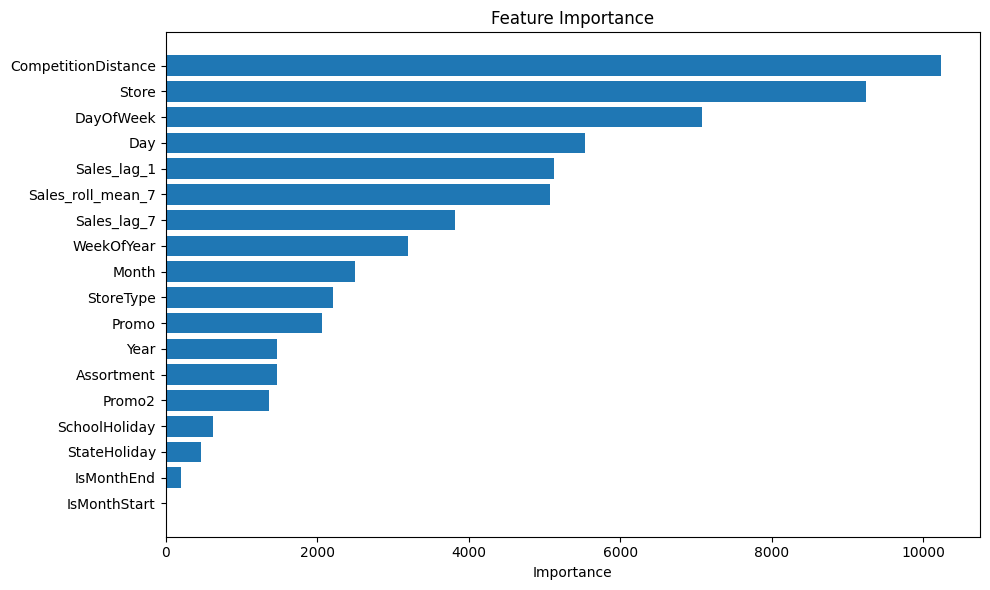

In [ ]:
import matplotlib.pyplot as plt

# 중요도 추출 + 정렬
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.gca().invert_yaxis()  # 큰 게 위로
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

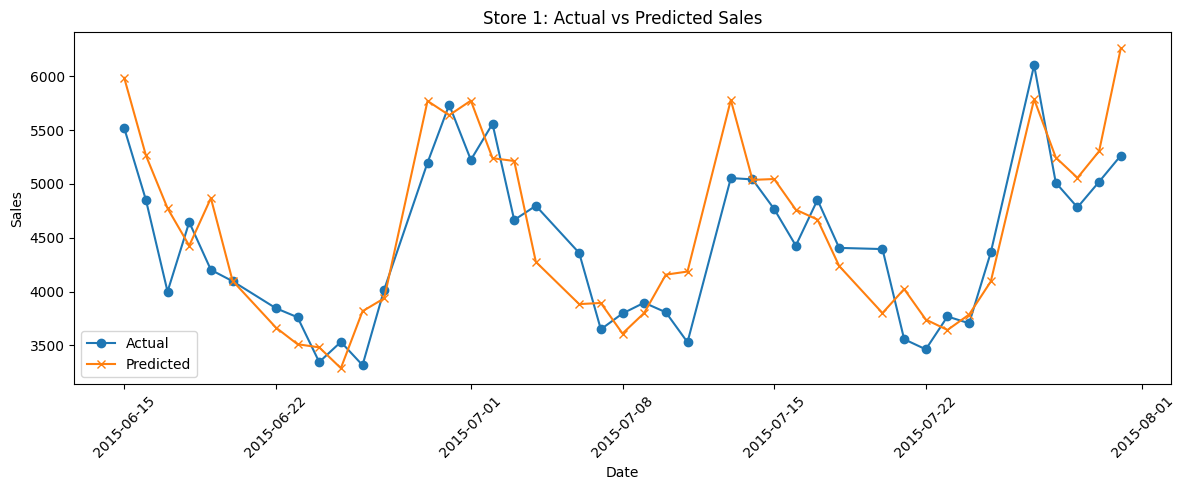

In [ ]:
# test_df에 예측값 붙이기
test_df = test_df.copy()
test_df['Pred'] = y_pred

# 1번 매장만 추출, 날짜순
store1 = test_df[test_df['Store'] == 1].sort_values('Date')

plt.figure(figsize=(12, 5))
plt.plot(store1['Date'], store1['Sales'], label='Actual', marker='o')
plt.plot(store1['Date'], store1['Pred'], label='Predicted', marker='x')
plt.title('Store 1: Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()